# Analisa Data Menggunakan Naive Bayes
## Studi Kasus: Klasifikasi Penyakit Diabetes

Proyek ini bertujuan untuk melakukan analisis data dan klasifikasi penyakit diabetes menggunakan algoritma **Naive Bayes** dengan bahasa pemrograman **Python** dan library **Scikit-Learn**.

**Dataset:** Pima Indians Diabetes Database  
**Link Kaggle:** https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database


# BAB 1. Pendahuluan

## 1.1 Latar Belakang
Diabetes merupakan salah satu penyakit kronis yang dapat menimbulkan berbagai komplikasi jika tidak terdeteksi sejak dini. Perkembangan teknologi data mining dan machine learning dapat membantu proses analisis data kesehatan untuk memprediksi kemungkinan seseorang terkena diabetes.

Salah satu metode klasifikasi yang sederhana dan banyak digunakan adalah **Naive Bayes**. Metode ini bekerja berdasarkan konsep probabilitas dan Teorema Bayes. Naive Bayes cocok digunakan untuk klasifikasi karena proses komputasinya cepat, sederhana, dan cukup efektif pada banyak kasus.

Pada proyek ini digunakan dataset **Pima Indians Diabetes Database** dari Kaggle untuk mengklasifikasikan apakah pasien memiliki indikasi diabetes atau tidak berdasarkan beberapa atribut kesehatan.

## 1.2 Rumusan Masalah
1. Bagaimana menerapkan algoritma Naive Bayes untuk klasifikasi diabetes?
2. Bagaimana hasil akurasi model Naive Bayes pada dataset diabetes?
3. Bagaimana hasil evaluasi model berdasarkan confusion matrix dan classification report?

## 1.3 Tujuan
1. Mengimplementasikan algoritma Naive Bayes menggunakan Python dan Scikit-Learn.
2. Melakukan preprocessing pada dataset diabetes.
3. Mengevaluasi performa model klasifikasi Naive Bayes.


# BAB 2. Tinjauan Pustaka

## 2.1 Klasifikasi
Klasifikasi adalah salah satu teknik supervised learning yang digunakan untuk memprediksi label kelas dari suatu data. Pada supervised learning, data training sudah memiliki label kelas sehingga model dapat belajar dari pola data tersebut.

## 2.2 Naive Bayes
Naive Bayes adalah algoritma klasifikasi berbasis probabilitas yang menggunakan Teorema Bayes. Algoritma ini disebut “naive” karena mengasumsikan bahwa setiap atribut atau fitur saling bebas satu sama lain terhadap kelas target.

Rumus Teorema Bayes:

$$P(C|X) = \frac{P(X|C) \times P(C)}{P(X)}$$

Keterangan:
- $P(C|X)$ = probabilitas kelas C jika diketahui data X
- $P(X|C)$ = probabilitas data X pada kelas C
- $P(C)$ = probabilitas awal kelas C
- $P(X)$ = probabilitas data X

Dalam klasifikasi, model memilih kelas dengan nilai probabilitas posterior terbesar.

## 2.3 Gaussian Naive Bayes
Karena dataset diabetes memiliki banyak fitur numerik seperti Glucose, BloodPressure, BMI, dan Age, maka model yang digunakan adalah **Gaussian Naive Bayes**. GaussianNB cocok untuk data numerik yang diasumsikan mengikuti distribusi normal.


# BAB 3. Metodologi

## 3.1 Dataset
Dataset yang digunakan adalah **Pima Indians Diabetes Database** dari Kaggle.

**Link dataset:** https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database

Dataset ini memiliki beberapa atribut kesehatan seperti:
- Pregnancies
- Glucose
- BloodPressure
- SkinThickness
- Insulin
- BMI
- DiabetesPedigreeFunction
- Age
- Outcome

Kolom **Outcome** adalah target klasifikasi:
- 0 = Tidak diabetes
- 1 = Diabetes

## 3.2 Catatan Penting Data Understanding
Catatan penting yang wajib dicantumkan dalam laporan:

1. Dataset hanya berisi **perempuan usia ≥ 21 tahun**.
2. Data berasal dari populasi **Pima Indian**.
3. Ada nilai **0 yang sebenarnya missing value**, terutama pada kolom seperti Glucose, BloodPressure, SkinThickness, Insulin, dan BMI.

Catatan ini penting karena mempengaruhi interpretasi hasil model. Model yang dibuat dari dataset ini belum tentu dapat langsung digeneralisasi untuk seluruh populasi.

## 3.3 Tahapan Analisis
Tahapan yang dilakukan pada proyek ini:
1. Import library
2. Load dataset
3. Data understanding
4. Data cleaning
5. Split data training dan testing
6. Training model Gaussian Naive Bayes
7. Evaluasi model
8. Kesimpulan


# 1. Import Library
Library yang digunakan adalah pandas, numpy, matplotlib, seaborn, dan scikit-learn.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print('Library berhasil diimport')

ModuleNotFoundError: No module named 'pandas'

# 2. Load Dataset

Ada dua cara menggunakan dataset:

## Cara A — Upload Manual ke Colab
1. Download dataset dari Kaggle.
2. Upload file `diabetes.csv` ke Google Colab.
3. Jalankan kode berikut.

## Cara B — Menggunakan Link CSV Alternatif
Jika belum bisa memakai Kaggle API, gunakan link CSV publik berikut.

In [19]:
url = 'https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv'
df = pd.read_csv(url)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# 3. Data Understanding
Pada tahap ini dilakukan pengecekan ukuran data, tipe data, missing value, dan statistik deskriptif.

In [20]:
print('Ukuran dataset:', df.shape)
print('\nInformasi dataset:')
df.info()

print('\nJumlah missing value:')
print(df.isnull().sum())

df.describe()

Ukuran dataset: (768, 9)

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Jumlah missing value:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                   

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Catatan Penting
Walaupun hasil `isnull()` menunjukkan tidak ada nilai kosong, pada dataset ini terdapat nilai **0** yang tidak realistis untuk beberapa atribut medis. Nilai 0 tersebut dianggap sebagai missing value.

Kolom yang perlu diperhatikan:
- Glucose
- BloodPressure
- SkinThickness
- Insulin
- BMI


In [21]:
kolom_missing_0 = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print('Jumlah nilai 0 pada kolom medis:')
print((df[kolom_missing_0] == 0).sum())

Jumlah nilai 0 pada kolom medis:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


# 4. Visualisasi Data
Visualisasi dilakukan untuk memahami distribusi target dan hubungan antar fitur.

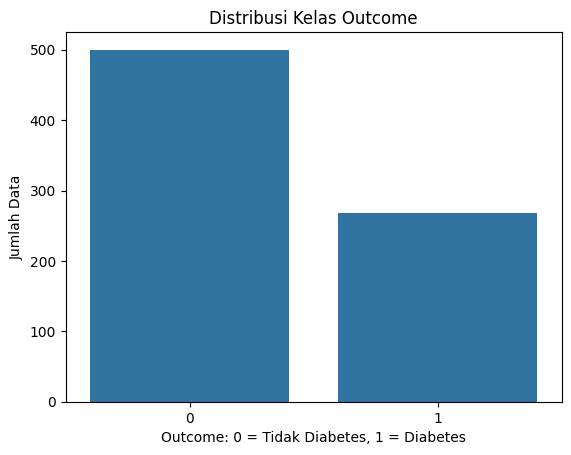

In [22]:
sns.countplot(x='Outcome', data=df)
plt.title('Distribusi Kelas Outcome')
plt.xlabel('Outcome: 0 = Tidak Diabetes, 1 = Diabetes')
plt.ylabel('Jumlah Data')
plt.show()

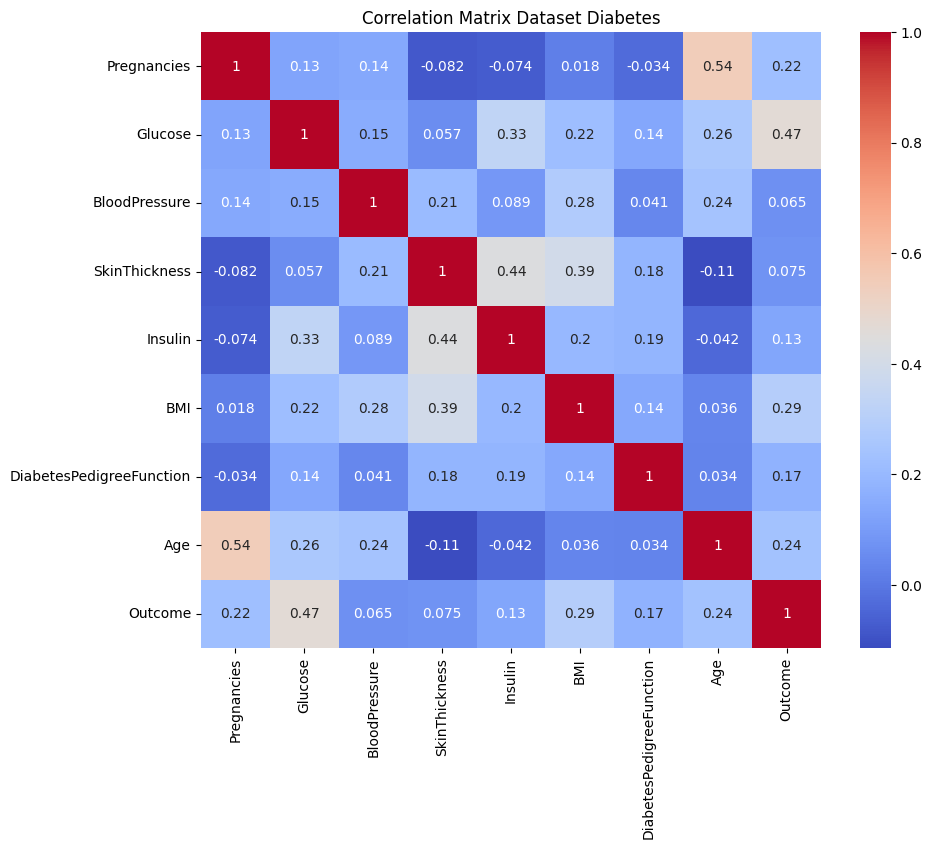

In [23]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix Dataset Diabetes')
plt.show()

# 5. Data Cleaning
Nilai 0 pada kolom medis tertentu diganti menjadi NaN, kemudian diisi menggunakan nilai median. Median dipilih karena lebih tahan terhadap data ekstrem dibandingkan mean.

In [24]:
df_clean = df.copy()

# Mengubah nilai 0 menjadi NaN pada kolom medis tertentu
df_clean[kolom_missing_0] = df_clean[kolom_missing_0].replace(0, np.nan)

print('Missing value setelah nilai 0 diganti NaN:')
print(df_clean.isnull().sum())

# Mengisi missing value dengan median
for kolom in kolom_missing_0:
    df_clean[kolom] = df_clean[kolom].fillna(df_clean[kolom].median())

print('\nMissing value setelah imputasi median:')
print(df_clean.isnull().sum())

Missing value setelah nilai 0 diganti NaN:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

Missing value setelah imputasi median:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


# 6. Menentukan Fitur dan Target
Fitur adalah variabel input, sedangkan target adalah kolom Outcome.

In [25]:
X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']

print('Fitur:')
print(X.columns.tolist())
print('\nTarget: Outcome')

Fitur:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Target: Outcome


# 7. Membagi Data Training dan Testing
Data dibagi menjadi 80% data training dan 20% data testing.

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Jumlah data training:', X_train.shape[0])
print('Jumlah data testing:', X_test.shape[0])

Jumlah data training: 614
Jumlah data testing: 154


# 8. Training Model Naive Bayes
Model yang digunakan adalah Gaussian Naive Bayes karena data berbentuk numerik.

In [27]:
model = GaussianNB()
model.fit(X_train, y_train)

print('Model Gaussian Naive Bayes berhasil dilatih')

Model Gaussian Naive Bayes berhasil dilatih


# 9. Prediksi Data Testing
Model digunakan untuk memprediksi data testing.

In [28]:
y_pred = model.predict(X_test)

hasil_prediksi = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

hasil_prediksi.head(10)

,Actual,Predicted
0,0,1
1,0,0
2,0,0
3,1,0
4,0,0
5,0,0
6,1,1
7,1,1
8,0,0
9,0,1


# 10. Evaluasi Model
Evaluasi dilakukan menggunakan accuracy, confusion matrix, dan classification report.

In [29]:
akurasi = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print('Accuracy:', akurasi)
print('\nConfusion Matrix:')
print(cm)
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

Accuracy: 0.7012987012987013

Confusion Matrix:
[[74 26]
 [20 34]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.74      0.76       100
           1       0.57      0.63      0.60        54

    accuracy                           0.70       154
   macro avg       0.68      0.68      0.68       154
weighted avg       0.71      0.70      0.70       154



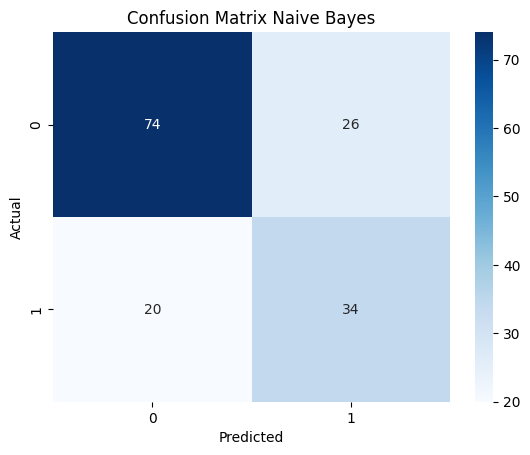

In [30]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix Naive Bayes')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Interpretasi Confusion Matrix
- **True Negative (TN):** pasien tidak diabetes dan diprediksi tidak diabetes.
- **True Positive (TP):** pasien diabetes dan diprediksi diabetes.
- **False Positive (FP):** pasien tidak diabetes tetapi diprediksi diabetes.
- **False Negative (FN):** pasien diabetes tetapi diprediksi tidak diabetes.

Dalam kasus medis, nilai **False Negative** perlu diperhatikan karena model gagal mendeteksi pasien yang sebenarnya memiliki diabetes.

# 11. Cross Validation
Cross validation digunakan untuk melihat performa model secara lebih stabil.

In [31]:
scores = cross_val_score(model, X, y, cv=5)

print('Hasil akurasi tiap fold:', scores)
print('Rata-rata akurasi cross validation:', scores.mean())

Hasil akurasi tiap fold: [0.74025974 0.73376623 0.74025974 0.79738562 0.73856209]
Rata-rata akurasi cross validation: 0.750046685340803


# BAB 4. Hasil dan Pembahasan

Berdasarkan hasil pengujian, model Gaussian Naive Bayes mampu melakukan klasifikasi terhadap data diabetes. Nilai akurasi menunjukkan seberapa banyak data testing yang berhasil diprediksi dengan benar.

Confusion matrix digunakan untuk melihat jumlah prediksi benar dan salah pada masing-masing kelas. Pada kasus prediksi penyakit, kesalahan berupa **False Negative** harus diperhatikan karena berarti pasien yang sebenarnya diabetes diprediksi tidak diabetes.

Model Naive Bayes memiliki kelebihan yaitu sederhana, cepat, dan mudah diimplementasikan. Namun, model ini memiliki kelemahan karena mengasumsikan setiap fitur saling bebas, padahal pada data medis beberapa fitur seperti Glucose, BMI, Age, dan Insulin dapat memiliki hubungan satu sama lain.


# BAB 5. Kesimpulan dan Saran

## 5.1 Kesimpulan
1. Algoritma Naive Bayes dapat digunakan untuk mengklasifikasikan penyakit diabetes berdasarkan dataset Pima Indians Diabetes.
2. Model Gaussian Naive Bayes cocok digunakan karena fitur pada dataset sebagian besar berupa data numerik.
3. Preprocessing penting dilakukan karena terdapat nilai 0 yang sebenarnya merupakan missing value pada beberapa kolom medis.
4. Evaluasi model dilakukan menggunakan accuracy, confusion matrix, classification report, dan cross validation.

